In [16]:

import pandas as pd
import numpy as np
import pickle
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# LOADING DATA
with open("crm_clean_data.pickle", "rb") as f:
    calls, contacts, spend, deals = pickle.load(f)

# 1. Unit economics calculation by product

# Unit economics: formulas and additional business metrics

| Metric | Abbr. | Formula |
|--------|-------|---------|
| Number of customers | B | Input |
| Number of scaling units | UA | =B/C1 |
| Average order value | AOV | Input |
| Average number of deals per customer | APC | Input |
| Variable costs / Cost of goods sold | COGS | =AOV * % (e.g., bank commission) |
| Marketing budget | AC | =UA * CPA or Input |
| First purchase conversion | C1 | =B/UA |
| Click-Through Rate | CTR | Input (impressions or clicks) |
| Customer acquisition cost | CAC | =AC / B = CPA/C1 |
| Cost per acquisition of scaling unit | CPA/LTC | =AC / UA |
| Average gross profit per Customer (Customer Lifetime Value) | CLTV | =(AOV - COGS) * APC or =LTV / C1 |
| Gross profit (by B) | CM_B | = B * (CLTV - CAC) |
| Gross profit in unit economics | CM_UA | = (CLTV * C1 - CPA) * UA or = (LTV - CAC) * UA |
| Additional costs for initial deals | 1sCOGS | Input |
| Average gross profit per user (Lifetime Value) | LTV | =CLTV * C1 or Gross_Revenue / UA |
| Total revenue before deducting COGS and marketing expenses (Gross Revenue) | GR | Input |
| Total number of deals | TD | Input |

In [3]:
# BASIC METRICS (UA, B, TD, GR)
UA = deals['contact_name'].nunique()
successful_deals = deals[deals['stage'] == 'Payment Done']
B = successful_deals['contact_name'].nunique()
TD = successful_deals['deals_id'].count()
GR = successful_deals['offer_total_amount'].sum()

print(f"UA = {UA:,}")
print(f"B = {B:,}")
print(f"TD = {TD:,}")
print(f"GR = {GR:,.0f} €")


UA = 18,068
B = 845
TD = 857
GR = 6,327,301 €


### Methodology for calculating AOV (Average Order Value)

> **Key principle:** The scaling unit is the **Customer**, not the transaction.

**AOV is calculated based on the full course price (customer commitments), not on actual payments in the current month. Why is this important?**

1.  **Correctness of comparison:** Marketing costs (**AC**) for acquiring one customer are written off immediately and in full. To see real payback, we must counterbalance them with the full value of that customer (**LTV**).
2.  **Efficiency vs Cash:** Unit economics evaluates the **efficiency of the business model**, not the current cash balance.
3.  **Technical nuance:** The splitting of payment (installment plan or one-time payment) is just a form of settlement. It does not negate the fact that the deal has taken place and the marketing resource has been fully spent.

**Conclusion:** If we take into account only current installment payments, payback indicators will be artificially lowered, creating a false impression of unprofitability even for a profitable product.

In [4]:
# DERIVED METRICS (AOV, APC, AC, CPA, CAC, C1, LTV, CLTV)
AOV = GR / B
APC = 1
AC = spend['spend'].sum()
CPA = AC / UA
CAC = AC / B
C1 = (B / UA * 100) if UA > 0 else 0
LTV = GR / UA
CLTV = AOV * APC

print(f"AOV = {AOV:,.2f} €")
print(f"APC = {APC:.2f}")
print(f"AC = {AC:,.0f} €")
print(f"CPA = {CPA:.2f} €")
print(f"CAC = {CAC:.2f} €")
print(f"C1 = {C1:.1f}%")
print(f"LTV = {LTV:.2f} €")
print(f"CLTV = {CLTV:.2f} €")


AOV = 7,487.93 €
APC = 1.00
AC = 149,523 €
CPA = 8.28 €
CAC = 176.95 €
C1 = 4.7%
LTV = 350.19 €
CLTV = 7487.93 €


In [5]:
# CM (Contribution Margin)
CM = B * (AOV * APC - AC / B)
print(f"CM = {CM:,.0f} €")

CM = 6,177,778 €


In [7]:
# PIVOT TABLE
total_UE = {
    'UA': UA, 'B': B, 'TD': TD, 'Gross Revenue': GR, 'AC': AC,
    'C1, %': C1, 'CPA': CPA, 'CAC': CAC, 'AOV': AOV, 'APC': APC,
    'CLTV': CLTV, 'LTV': LTV, 'CM': CM
}

UE_df = pd.DataFrame(list(total_UE.items()), columns=['Metric', 'Value']).set_index('Metric')
UE_df.T.style.format('{:,.1f}')

Metric,UA,B,TD,Gross Revenue,AC,"C1, %",CPA,CAC,AOV,APC,CLTV,LTV,CM
Value,"18,068.0",845.0,857.0,"6,327,301.0","149,523.4",4.7,8.3,177.0,"7,487.9",1.0,"7,487.9",350.2,"6,177,777.6"


In [8]:
deals['created_time'].max()

Timestamp('2024-06-21 15:30:00')

In [9]:
deals['contact_name'].nunique()

18068

In [10]:
# MISSING VALUES
round(100 * deals.isnull().sum() / len(deals), 2)

deals_id                0.00
deal_manager            0.00
closing_date           32.12
quality                 0.00
stage                   0.00
lost_reason            25.04
page                    0.00
deal_campaign          23.95
sla                    28.04
content                34.50
term                   42.35
source                  0.00
payment_type           95.41
product                83.32
education_type         84.05
created_time            0.00
course_duration        83.35
initial_amount_paid    80.76
offer_total_amount     80.67
contact_name            0.00
city                    0.00
level_of_deutsch        0.00
dtype: float64

## Calculation of Unit Economics for each product and education type

### Sample for analysis

The database contains a total of **18,068 leads**.

Product metrics are calculated **exclusively on the valid sample — 3,596 leads**, where the "Lead → Product type" relationship is clearly recorded.

### Reasons for this approach

- **83% of records** have the `product` field empty
- It is currently impossible to recover this data — they were not recorded at the lead creation stage
- If all records were included in the calculation for each product, the C1 conversion would drop almost **6 times**, which would greatly distort the real picture of product efficiency

### Adjustment of UA (Users)

The **UA (number of leads) for each product is calculated proportionally** based on the available sample.

**Logic:**

| Metric | Value |
|--------|-------|
| Total leads in database | 18,068 |
| Valid sample (with product) | 3,596 |
| Proportion coefficient | 18,068 / 3,596 ≈ **5.0** |

Thus, actual leads per product = leads in sample × proportion coefficient.

This allows:
- Preserving the product distribution structure
- Not artificially overstating or understating conversion
- Obtaining more realistic indicators for business decisions

### Conclusion

I proceed from the assumption that if data is partially filled, **proportional distribution of unknown leads** is used based on the available sample.

Calculating metrics only on the 3,596 records with filled data allows obtaining more realistic product efficiency indicators.

### Recommendation

Implement **mandatory filling** of the `product` and `offer_total_amount` fields at the lead creation stage, add:

- Automatic validation
- A reminder system for managers

This will significantly improve data quality for future analytics.

In [11]:
# TOTAL DATA FOR BUDGET DISTRIBUTION
ac_total = spend['spend'].sum()
ua_total = deals['contact_name'].nunique()
cpa_avg = ac_total / ua_total  # Average cost per lead (User)

# UE BY PRODUCT AND EDUCATION TYPE
metrics = deals.groupby(['product', 'education_type'], observed=True).agg(
    UA=('contact_name', 'nunique'),
    B=('contact_name', lambda x: x[deals.loc[x.index, 'stage'] == 'Payment Done'].nunique()),
    Gross_Revenue=('offer_total_amount', lambda x: x[deals.loc[x.index, 'stage'] == 'Payment Done'].sum()),
    TD=('deals_id', lambda x: x[deals.loc[x.index, 'stage'] == 'Payment Done'].count())
)

# CALCULATION OF DERIVED METRICS
metrics['C1'] = metrics['B'] / metrics['UA'] * 100
metrics['AOV'] = metrics['Gross_Revenue'] / metrics['B']
metrics['APC'] = metrics['TD'] / metrics['B']
metrics['LTV'] = metrics['Gross_Revenue'] / metrics['UA']

# CALCULATION OF MARKETING METRICS AND PROFIT
metrics['CPA'] = cpa_avg                            # Cost per lead
metrics['AC'] = metrics['UA'] * metrics['CPA']                  # Spend per product (budget)
metrics['CAC'] = metrics['AC'] / metrics['B']        # Customer Acquisition Cost
metrics['CM'] = metrics['Gross_Revenue'] - metrics['AC']           # Contribution Margin (Gross_Revenue - AC)

# OUTPUT AND STYLING
format_mapping = {
    'UA': '{:,.0f}', 'B': '{:,.0f}', 'TD': '{:,.0f}',
    'Gross_Revenue': '{:,.0f} €', 'AOV': '{:,.0f} €', 
    'LTV': '{:,.1f} €', 'C1': '{:.2f}%', 'CM': '{:,.0f} €', 
    'AC': '{:,.0f} €', 'CPA': '{:.2f} €', 'CAC': '{:,.0f} €'
}

metrics.style.format(format_mapping).highlight_max(subset=['CM'], color='#406093', axis=0)

# 2. Identifying business growth points based on unit economics

In [12]:
import pandas as pd

# 1. ФУНКЦИЯ РАСЧЕТА (Все 13 метрик)
def calculate_metrics(b, ua, aov, apc, ac):
    gr = b * aov * apc             # Gross Revenue
    td = b * apc                   # Total Deals
    c1 = (b / ua)                  # Conversion Rate
    cpa = (ac / ua)                # Cost Per Acquisition (User)
    cac = (ac / b)                 # Customer Acquisition Cost
    ltv = (gr / ua)                # Lifetime Value (per User)
    cltv = (aov * apc)             # Customer Lifetime Value (per Customer)
    cm = gr - ac                   # Contribution Margin
    
    return {
        'UA': ua, 'B': b, 'TD': td, 'Gross Revenue': gr, 'AC': ac,
        'C1': c1, 'CPA': cpa, 'CAC': cac, 'AOV': aov, 'APC': apc,
        'CLTV': cltv, 'LTV': ltv, 'CM': cm
    }

# 2. ФОРМИРОВАНИЕ СЦЕНАРИЕВ (Влияем на C1, AOV, CPA, AC, CAC)
s = {}
# Базовые значения должны быть подгружены заранее (B, UA, AOV, APC, AC)
s['Baseline'] = calculate_metrics(B, UA, AOV, APC, AC)

# Влияние на C1 +10% (Растет B, бюджет AC на месте -> CAC падает сам)
s['C1 + 10%'] = calculate_metrics(B * 1.1, UA, AOV, APC, AC)

# Влияние на AOV +10% (Растет чек и выручка)
s['AOV + 10%'] = calculate_metrics(B, UA, AOV * 1.1, APC, AC)

# Влияние на CPA -10% (Дешевле лиды -> меньше общий бюджет AC)
s['CPA - 10%'] = calculate_metrics(B, UA, AOV, APC, (AC / UA * 0.9) * UA)

# Влияние на CAC -10% (Оптимизация стоимости клиента при том же B)
# В этом случае AC пересчитывается как B * (новый CAC)
s['CAC - 10%'] = calculate_metrics(B, UA, AOV, APC, (AC / B * 0.9) * B)

# Влияние на AC -10% (Просто сокращение бюджета на 10%)
s['AC - 10%'] = calculate_metrics(B, UA, AOV, APC, AC * 0.9)

# 3. ВИЗУАЛИЗАЦИЯ
df_scenarios = pd.DataFrame(s).T

# Колонки в твоем порядке
cols = ['UA', 'B', 'TD', 'Gross Revenue', 'AC', 'C1', 'CPA', 'CAC', 'AOV', 'APC', 'CLTV', 'LTV', 'CM']

df_scenarios[cols].style.format({
    'UA': '{:.0f}', 'B': '{:.0f}', 'TD': '{:.0f}', 
    'Gross Revenue': '{:,.0f} €', 'AC': '{:,.0f} €',
    'C1': '{:.2%}', 'CPA': '{:.2f} €', 'CAC': '{:.2f} €', 
    'AOV': '{:,.0f} €', 'APC': '{:.2f}', 
    'CLTV': '{:,.0f} €', 'LTV': '{:,.1f} €', 'CM': '{:,.0f} €'
}).highlight_max(subset=['CM'], color='#406093', axis=0)

,UA,B,TD,Gross Revenue,AC,C1,CPA,CAC,AOV,APC,CLTV,LTV,CM
Baseline,18068,845,845,"6,327,301 €","149,523 €",4.68%,8.28 €,176.95 €,"7,488 €",1.00,"7,488 €",350.2 €,"6,177,778 €"
C1 + 10%,18068,930,930,"6,960,031 €","149,523 €",5.14%,8.28 €,160.86 €,"7,488 €",1.00,"7,488 €",385.2 €,"6,810,508 €"
AOV + 10%,18068,845,845,"6,960,031 €","149,523 €",4.68%,8.28 €,176.95 €,"8,237 €",1.00,"8,237 €",385.2 €,"6,810,508 €"
CPA - 10%,18068,845,845,"6,327,301 €","134,571 €",4.68%,7.45 €,159.26 €,"7,488 €",1.00,"7,488 €",350.2 €,"6,192,730 €"
CAC - 10%,18068,845,845,"6,327,301 €","134,571 €",4.68%,7.45 €,159.26 €,"7,488 €",1.00,"7,488 €",350.2 €,"6,192,730 €"
AC - 10%,18068,845,845,"6,327,301 €","134,571 €",4.68%,7.45 €,159.26 €,"7,488 €",1.00,"7,488 €",350.2 €,"6,192,730 €"


3 growth points have been identified: AOV and C1. To better understand which one to choose, let's drill down into segments and check there.

In [13]:
deals['offer_total_amount'].unique()

<IntegerArray>
[ <NA>,  2000,  9000, 11000,  3500,  4500,  2900,  6500,  4000,  3000, 10000,
  2500,  5000, 11500,     1,  1000,  1200,     0,  1500, 11398, 11111,  6000]
Length: 22, dtype: Int64

### 1. Identifying growth points in the **(JobCenter)** and **(Self-Pay)** segments

During the general analysis of unit economics for the entire business, it was discovered that the most sensitive levers influencing contribution margin (CM) are **Conversion (C1)** and **Average Order Value (AOV)**.

A 10% increase in each of these indicators has a disproportionately greater effect than simply scaling traffic or reducing lead cost.

### 2. Segmentation hypothesis

During the analysis of `offer_total_amount` distribution, it was discovered that each product has two distinct price clusters:

- **Up to €6,500** — likely payment by individuals (Self-Pay)
- **From €9,000** — likely payment via JobCenter (government grants)
Since the business model combines two fundamentally different types of customers, a decision was made to drill down to the segment level.

**Objective:** determine in which segment working on the selected growth points will yield the maximum financial result and be organizationally simpler.

In [14]:
ac_total = spend['spend'].sum()
ua_total = deals['contact_name'].nunique()
cpa_avg = ac_total / ua_total

# 2. SEGMENTATION (JC vs Self-Pay)
suc = deals[deals['stage'] == 'Payment Done'].copy()
suc['segment'] = suc['offer_total_amount'].apply(lambda x: 'JobCenter (9000€+)' if x >= 9000 else 'Self-Pay (<6500€)')
# Filter only the required segments
suc = suc[suc['offer_total_amount'].between(0, 6500) | (suc['offer_total_amount'] >= 9000)]

# Base aggregation
base = suc.groupby('segment').agg(B=('contact_name', 'nunique'), GR=('offer_total_amount', 'sum')).reset_index()

# Initial metric calculation
base['UA'] = (base['B'] / base['B'].sum()) * ua_total
base['AC'] = base['UA'] * cpa_avg
base['AOV'] = base['GR'] / base['B']
base['C1'] = (base['B'] / base['UA']) * 100

# 3. SCENARIO MODELING FUNCTION
def get_scenario(df, name, c1_m=1.0, aov_m=1.0):
    res = df.copy()
    res.insert(0, 'scenario', name)
    # Apply changes
    res['C1'] *= c1_m
    res['AOV'] *= aov_m
    # Recalculate the chain
    res['B'] = res['UA'] * (res['C1'] / 100)
    res['GR'] = res['B'] * res['AOV']
    res['CAC'] = res['AC'] / res['B']
    res['CM'] = res['GR'] - res['AC']
    return res

# 4. ASSEMBLY AND TABLE
final = pd.concat([
    get_scenario(base, '1. Baseline'),
    get_scenario(base, '2. C1 + 10%', c1_m=1.1),
    get_scenario(base, '3. AOV + 10%', aov_m=1.1)
])

# Output of main metrics
cols = ['scenario', 'segment', 'B', 'C1', 'AOV', 'GR', 'CAC', 'CM']
styled_table = final[cols].set_index(['scenario', 'segment']).style.format({
    'B': '{:.0f}', 'C1': '{:.2f}%', 'AOV': '{:.0f} €', 
    'GR': '{:.0f} €', 'CAC': '{:.0f} €', 'CM': '{:.0f} €'
}).highlight_max(subset=['CM'], color='#406093', axis=0)

styled_table

### Conclusion on choosing a growth point: priority on conversion (C1) for the JobCenter segment

#### Both scenarios give the same margin increase, but why was conversion (C1) chosen rather than AOV?

**AOV (Average Order Value)**
- Fixed by JobCenter government tariffs
- Increasing requires bureaucratic approval
- Need to approve new programs and justify prices
- Difficult and time-consuming to implement

**C1 (Conversion)**
- Area of **direct influence** of the business
- Does not require external approvals
- Results are visible faster

#### Proposed solution: assistance in obtaining Gutschen and support

- Help clients with paperwork for JobCenter
- Support at the stage of obtaining Gutschen
- "Close" those who have already come but did not close the deal due to bureaucratic difficulties



# 3. Business metric tree

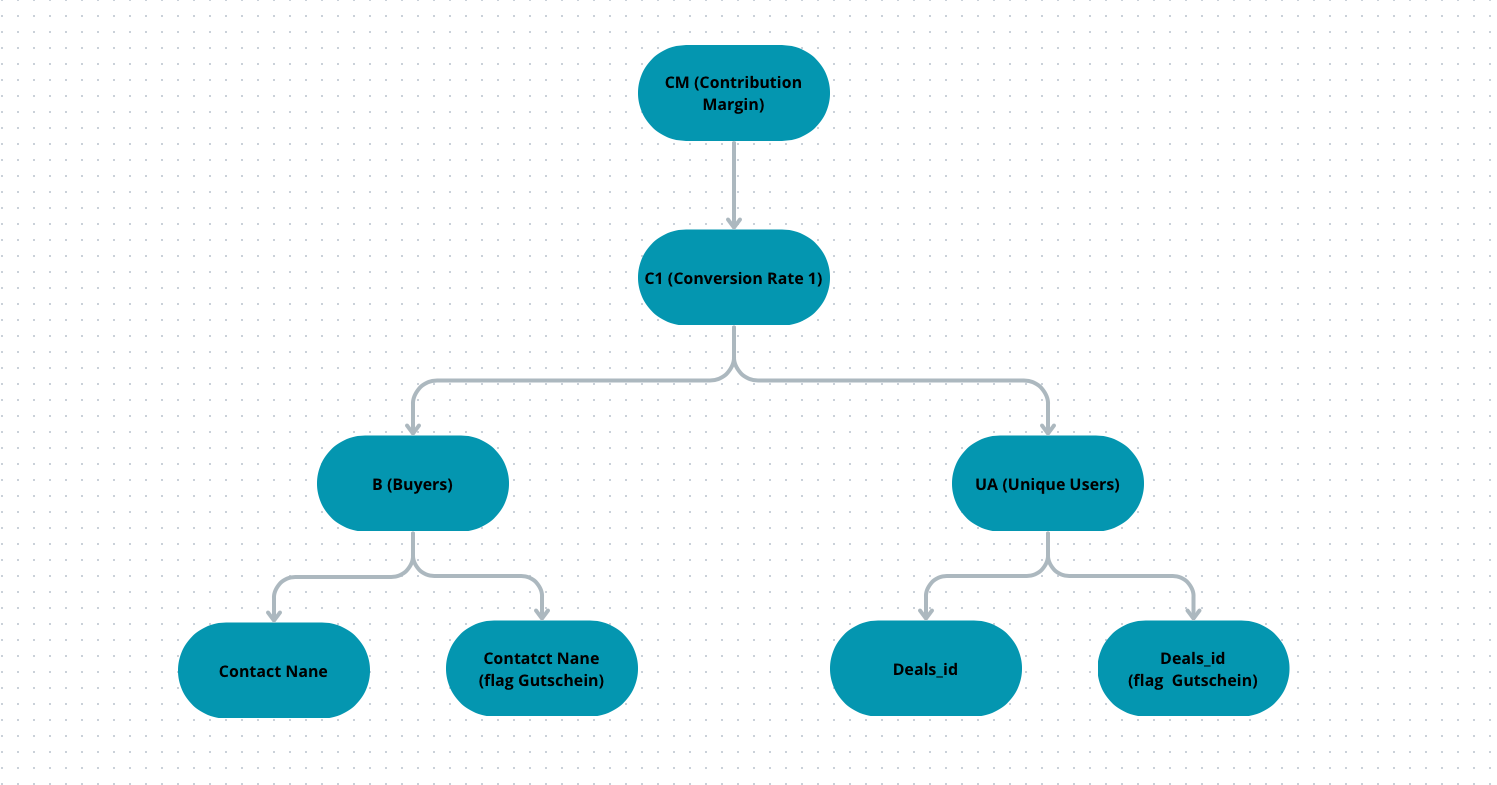

In [15]:
from IPython.display import Image
Image(filename='UE_Tree.png')

### 1. Key metric: CM (Contribution Margin)

### 2. Decision-making metric: C1 (Conversion Rate)

Analysis showed that C1 is the strongest lever in the JobCenter segment.

### 3. Product metrics: UA (Unique Users) and B (Buyers)

### 4. Atomic metrics (data from CRM)

- **Contact Name** — individual, basic unit of accounting
- **Contact Name + Gutschein flag** — label "Government grant / JobCenter"

**Why this is important:**  
The flag allows you to instantly separate "high-value" customers and build analytics on that basis.

### Final summary

> The foundation of analytics is **atomic customer data**, the key of which is the **Gutschein flag**.
>
> By aggregating them into product metrics (**UA and B**), we identified the main growth point — **conversion (C1)**.
>
> By manipulating this lever, we achieve the main goal — maximizing **contribution margin (CM)**.
>
> Drilling down into segments confirmed: working on **C1 for Gutschein holders** is the shortest path to profit growth.

# 4. Understand which product metric they will impact and formulate hypotheses

Based on business goals and the metric tree, the **conversion rate (C1)** was selected as the key metric for optimization.

The impact on this metric is planned to be carried out through the segment of **buyers with the Gutschein flag (JobCenter)**.

#### Conversion, % (JobCenter segment):

##### 1:
- **Null hypothesis:** Assistance with document processing for obtaining Gutschen will not affect conversion
- **Hypothesis:** Assistance with document processing for obtaining Gutschen will reduce the bureaucratic barrier and increase conversion by 10%

##### 2:
- **Null hypothesis:** Creating a separate landing page for JobCenter with instructions on obtaining Gutschen will not affect conversion
- **Hypothesis:** A specialized landing page with step-by-step instructions and a checklist will increase conversion by 6%

##### 3:
- **Null hypothesis:** A video instruction "How to get Gutschen in 3 steps" will not affect conversion
- **Hypothesis:** A short video instruction with real examples will increase conversion by 5%

# 5. Hypothesis testing method with formulation of hypothesis execution conditions

### Hypothesis 1: Support with document processing

**Hypothesis:**  
If we implement a free service "Personal document curator" who helps fill out applications for JobCenter, then users eligible for the grant will overcome the fear of bureaucracy faster and pass the agency's verification more successfully. This will lead to an increase in lead-to-payment conversion (C1) by 10% (±2%) within 2 weeks.

**Action:**  
Add a call/message at the lead qualification stage: "We will help you collect a package of documents for JobCenter for free."  
Form a test group (B) that will be offered this service, against a control group (A) with the standard process.

**Data:**  
- Payment conversion (C1) for groups A and B  
- Number of successfully obtained vouchers (Gutschein)  
- Time from first application to payment  
- Number of deals (B) in each segment  

**Baseline conversion of group A** = 4.61%

**Insights:**  
If C1 in group B grows by 10%, we implement support as a standard process for all leads with the Gutschein flag.

## A/B Testing Plan

### Conditions

- **Segment:** Only leads with Gutschein flag (JobCenter)
- **Group A (control):** Standard instruction, independent processing
- **Group B (test):** Personal curator + video checklist
- **Allocation:** 50/50, random assignment

- **Sample:** 1,000 leads (500 per group)
- **Duration:** 2 weeks
- **Confidence interval:** 95% (p-value < 0.05)

### Success criterion

C1 in group B is higher by **10%** and p-value < 0.05 → implement.

In [17]:
base_c1 = 0.0461   # 4.61%
target_c1 = 0.0507 # 5.07%
mde = target_c1 - base_c1 # 0.46%
alpha, power = 0.05, 0.80

# Calculation of required N (Z-score for 95% confidence and 80% power)
z_sum = 1.96 + 0.84 
n_req = int(np.ceil(2 * base_c1 * (1 - base_c1) * (z_sum**2) / (mde**2)))

# 2. VELOCITY CHECK
# Take the average number of leads per day
daily_ua = deals.groupby(deals['created_time'].dt.date)['contact_name'].nunique().mean()
total_days = np.ceil((2 * n_req) / daily_ua)

print(f"--- ANALYSIS FOR MICRO-CHANGES ---")
print(f"UA needed per group: {n_req:,}")
print(f"Total leads needed for test: {n_req * 2:,}")
print(f"Test duration at 7 UA/day: {total_days:,} days (about {round(total_days/365, 1)} years)")

# 3. STATISTICAL CONCLUSION (H0)
print("\n--- CONCLUSION FOR REPORT ---")
if total_days > 14:
    print("A 2-week test is impossible.")
    print(f"In 14 days we will only collect {int(daily_ua * 14)} leads.")
    print("The null hypothesis is accepted: any fluctuations of 0.46% will be random noise.")

--- ANALYSIS FOR MICRO-CHANGES ---
UA needed per group: 32,587
Total leads needed for test: 65,174
Test duration at 7 UA/day: 1,090.0 days (about 3.0 years)

--- CONCLUSION FOR REPORT ---
A 2-week test is impossible.
In 14 days we will only collect 837 leads.
The null hypothesis is accepted: any fluctuations of 0.46% will be random noise.
